# Curvature-aware SPH boundary integrals — demo

The semi-analytic SPH boundary integral (Winchenbach, Akhunov, Kolb 2020)

$$\lambda(x) = \int_{\mathcal D_B(x)} W(|x-x'|,h)\,dx' , \qquad
W(r,h) = \frac{C_n}{h^n}\,\hat W(q),\quad q = r/h$$

depends on the particle's signed distance to the boundary.  This repository
derives **closed forms** for it, beyond the paper's 3-D planar cubic-spline
result:

| extension | status |
|---|---|
| 2-D planar, all 4 kernels | **new** — arccos/ln closed forms (§2) |
| 3-D planar, Wendland w2/w4/w6 | **new** — single polynomials (§3) |
| curved boundary: solid sphere, Wendland | **new** — rational in R, d (§4) |
| 3-D planar cubic spline | paper eq. (18), reproduced exactly (§3) |

Everything plotted below is evaluated from the Maple-generated closed forms
in `src/warpSPHBoundaries/data/symbolic/` (regenerate with `maple/run_all.sh`); the independent
mpmath oracles in `src/warpSPHBoundaries/curvbound/oracle.py` validate them (§5).

*Conventions:* unit support `h = 1` (so `d` below means `d/h`), particle
**outside** the boundary, kernels as in warpSPHCore (`q = r/h`, `h` = support
radius).  The 2-D geometry is the focus — it is what makes the shell
measures and the branch structure easy to visualize.

In [1]:

import os
from pathlib import Path
from fractions import Fraction

import mpmath as mp
import numpy as np
import matplotlib.pyplot as plt

_here = Path(os.getcwd())
REPO = _here if (_here / "notebooks").exists() else _here.parent
import sys
sys.path.insert(0, str(REPO / "python"))
from curvbound import KERNELS, planar2d, planar3d, sphere
from curvbound.oracle import quad_planar2d, quad_planar3d, quad_sphere

FIG = REPO / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
mp.mp.dps = 40
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})
K = ["cubic", "w2", "w4", "w6"]
COLORS = {"cubic": "tab:red", "w2": "tab:blue", "w4": "tab:green", "w6": "tab:purple"}

for k, kd in KERNELS.items():
    print(f"{k:6s}  C2 = {kd.c2_pi}/pi   C3 = {kd.c3_pi}/pi")


cubic   C2 = 80/7/pi   C3 = 16/pi
w2      C2 = 7/pi   C3 = 21/2/pi
w4      C2 = 9/pi   C3 = 495/32/pi
w6      C2 = 78/7/pi   C3 = 1365/64/pi


## 1. The 2-D geometry: one chord per shell

Particle at the origin, planar boundary the line `y = d`, boundary side
`y > d`.  The support disk (radius `h = 1`) is cut by the line; the boundary
region $\mathcal D_B$ is the disk part beyond the line.  A radius-`q` shell
contributes the **arc** $s(q) = 2q\,\arccos(d/q)$ (for `q >= d`), so

$$\lambda_2(d) = \int_d^1 C_2\,\hat W(q)\, 2q\,\arccos\!\tfrac{d}{q}\, dq .$$

Note the **single power of q** in the shell measure — this is what makes the
2-D integral different from the 3-D one, and it is what the antiderivative
`v0(q) = Int_0^q t W(t) dt` in §2 must use.

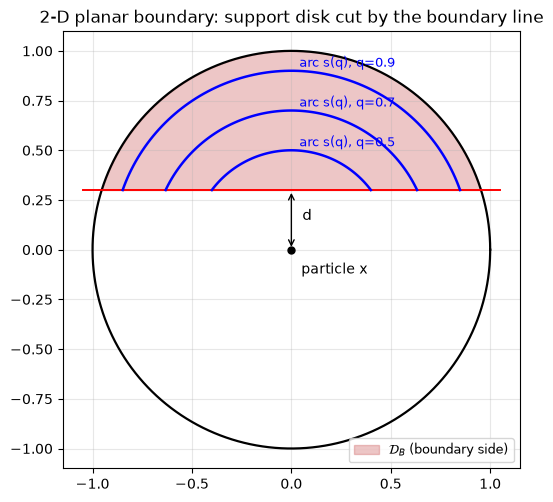

In [2]:

import numpy as np, matplotlib.pyplot as plt

d = 0.3
fig, ax = plt.subplots(figsize=(5.4, 5.4))
t = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(t), np.sin(t), "k-", lw=1.6)                      # support disk
xx = np.linspace(-np.sqrt(1 - d**2), np.sqrt(1 - d**2), 300)
ax.fill_between(xx, d, np.sqrt(1 - xx**2),
                color="indianred", alpha=0.35, label=r"$\mathcal{D}_B$ (boundary side)")
ax.plot([-1.05, 1.05], [d, d], "r-", lw=1.4)
ax.annotate("", xy=(0, d), xytext=(0, 0),
            arrowprops=dict(arrowstyle="<->", color="k"))
ax.text(0.03, d/2, " d ", fontsize=11)
for q in [0.5, 0.7, 0.9]:
    a = np.arccos(d/q)
    tt = np.linspace(-a, a, 100)
    ax.plot(q*np.sin(tt), q*np.cos(tt), "b-", lw=1.8)
    ax.text(0.04, q + 0.02, f"arc s(q), q={q}", fontsize=9, color="b")
ax.plot(0, 0, "ko", ms=5)
ax.text(0.05, -0.12, "particle x", fontsize=10)
ax.set_aspect("equal"); ax.set_xlim(-1.15, 1.15); ax.set_ylim(-1.1, 1.1)
ax.set_title(r"2-D planar boundary: support disk cut by the boundary line")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout(); fig.savefig(FIG / "fig1_geometry_2d.png", bbox_inches="tight")
plt.show()


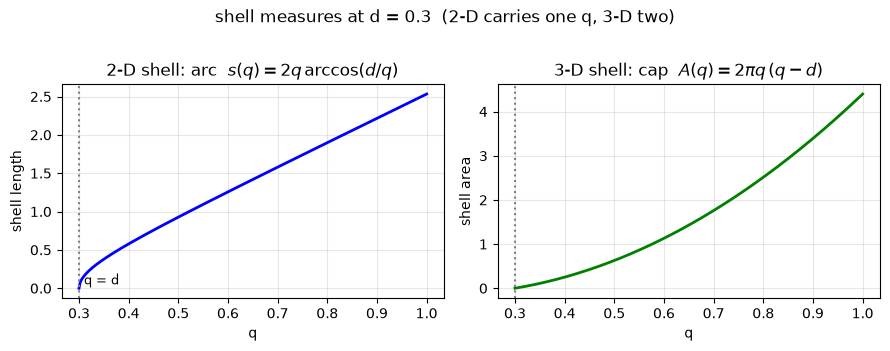

In [3]:

# shell measures: 2-D arc length vs 3-D cap area, same d
d = 0.3
q = np.linspace(d + 1e-9, 1.0, 300)
s2 = 2*q*np.arccos(d/q)
A3 = 2*np.pi*q*(q - d)
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.4), sharey=False)
axes[0].plot(q, s2, "b-", lw=2)
axes[0].set_title(r"2-D shell: arc  $s(q) = 2q\,\arccos(d/q)$")
axes[0].set_xlabel("q"); axes[0].set_ylabel("shell length")
axes[0].axvline(d, ls=":", c="grey"); axes[0].text(d + 0.01, 0.05, "q = d", fontsize=9)
axes[1].plot(q, A3, "g-", lw=2)
axes[1].set_title(r"3-D shell: cap  $A(q) = 2\pi q\,(q-d)$")
axes[1].set_xlabel("q"); axes[1].set_ylabel("shell area")
axes[1].axvline(d, ls=":", c="grey")
fig.suptitle(f"shell measures at d = {d}  (2-D carries one q, 3-D two)", y=1.02)
fig.tight_layout(); fig.savefig(FIG / "fig2_shell_measures.png", bbox_inches="tight")
plt.show()


## 2. The 2-D planar integral $\lambda_2(d)$

Maple cannot close $\int \text{poly}(q)\,\arccos(d/q)\,dq$ directly, but by
parts with $u = \arccos(d/q)$ and $dv = 2C_2 q\hat W(q)\,dq$:

$$\lambda_2(d) = 2C_2\Big[ v_0(1)\,\arccos d \;-\; d\int_d^1
\frac{v_0(q)}{q\sqrt{q^2-d^2}}\,dq\Big],
\qquad v_0(q) = \int_0^q t\,\hat W(t)\,dt\ \ \textbf{(one power of t)}$$

reduces the problem to $J_m(d) = \int_d^1 q^m/\sqrt{q^2-d^2}\,dq$, which
closes for every $m$ to $\text{poly}(d)\sqrt{1-d^2} + \text{poly}\cdot
\ln d + \text{poly}\cdot \ln(1+\sqrt{1-d^2})$.

* **Wendland w2/w4/w6**: one closed form each (single kernel polynomial).
* **Cubic spline**: the knot at $q=\tfrac12$ splits the integral; branch A
  ($d \le \tfrac12$) additionally contains $\arccos(2d)$, $\sqrt{1-4d^2}$,
  $\ln(1+\sqrt{1-4d^2})$.  The branches join **exactly** at $d=\tfrac12$:

$$\lambda_2(1/2) = \frac{64\pi - 294\sqrt3 + 249\ln(2+\sqrt3)}{168\pi}
\approx 0.03748 .$$

Boundary values are exact for all four kernels: $\lambda_2(0) = \tfrac12$,
$\lambda_2(1) = 0$.

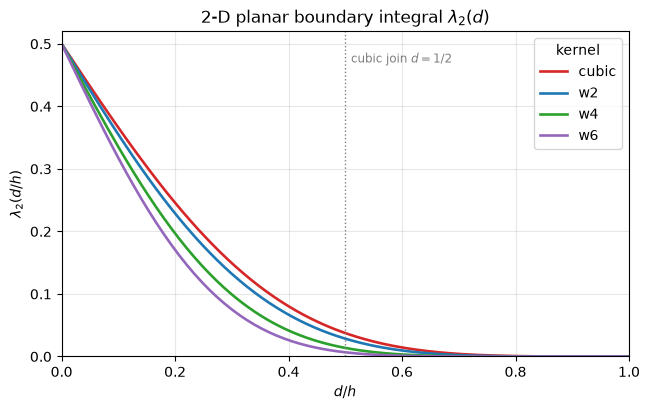

In [4]:

# lambda_2(d) for all four kernels, 40-digit closed forms
dgrid = np.linspace(1e-6, 1 - 1e-6, 151)
fig, ax = plt.subplots(figsize=(6.6, 4.2))
for k in K:
    ys = [0.5] + [float(planar2d(k, mp.mpf(x))) for x in dgrid] + [0.0]
    ax.plot([0] + list(dgrid) + [1], ys, color=COLORS[k], lw=1.9, label=k)
ax.axvline(0.5, ls=":", c="grey", lw=1)
ax.text(0.51, 0.47, r"cubic join $d = 1/2$", fontsize=8.5, color="grey")
ax.set_xlabel(r"$d/h$"); ax.set_ylabel(r"$\lambda_2(d/h)$")
ax.set_title(r"2-D planar boundary integral $\lambda_2(d)$")
ax.legend(title="kernel"); ax.set_xlim(0, 1); ax.set_ylim(0, 0.52)
fig.tight_layout(); fig.savefig(FIG / "fig3_lambda_2d.png", bbox_inches="tight")
plt.show()


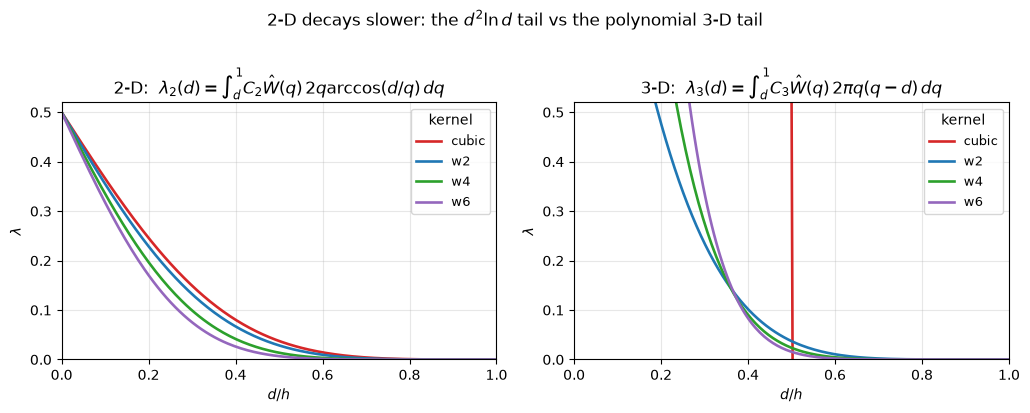

In [5]:

# 2-D vs 3-D side by side: same kernels, different shell measures
from curvbound.symbolic import _load_planar
data = _load_planar()

def lam3_np(k, dg):
    if k == "cubic":
        c1 = np.array([float(c) for c in data["3d"][("cubic", "b1")]])
        c2 = np.array([float(c) for c in data["3d"][("cubic", "b2")]])
        y = np.where(dg <= 0.5,
                     np.polyval(c1[::-1], dg), np.polyval(c2[::-1], dg))
    else:
        c = np.array([float(c) for c in data["3d"][(k, "all")]])
        y = np.polyval(c[::-1], dg)
    return y

dgrid = np.linspace(0, 1, 200)
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.0))
for k in K:
    axes[0].plot(dgrid, [0.5] + [float(planar2d(k, mp.mpf(x))) for x in dgrid[1:-1]] + [0.0],
                 color=COLORS[k], lw=1.9, label=k)
    axes[1].plot(dgrid, lam3_np(k, dgrid), color=COLORS[k], lw=1.9, label=k)
axes[0].set_title(r"2-D:  $\lambda_2(d) = \int_d^1 C_2\hat W(q)\,2q\arccos(d/q)\,dq$")
axes[1].set_title(r"3-D:  $\lambda_3(d) = \int_d^1 C_3\hat W(q)\,2\pi q(q-d)\,dq$")
for a in axes:
    a.set_xlabel(r"$d/h$"); a.legend(title="kernel", fontsize=9); a.set_xlim(0, 1)
    a.set_ylim(0, 0.52); a.set_ylabel(r"$\lambda$")
fig.suptitle("2-D decays slower: the $d^2\\ln d$ tail vs the polynomial 3-D tail", y=1.02)
fig.tight_layout(); fig.savefig(FIG / "fig4_2d_vs_3d.png", bbox_inches="tight")
plt.show()


## 3. The 3-D planar integral $\lambda_3(d)$

The paper's cubic-spline result (eq. 18) is reproduced **exactly** by the
Maple derivation, and the Wendland kernels need no branch split at all:
with the monomial basis $F(n,p,x) = \int_0^x t^p(1-t)^n dt$,

$$\lambda_3(d) = 2\pi C_3 \sum_p c_p\Big[F(n,p{+}2,1) - F(n,p{+}2,d)
- d\big(F(n,p{+}1,1) - F(n,p{+}1,d)\big)\Big]$$

is a **single polynomial in d of degree 2n** (8, 11, 14 for w2/w4/w6), with
exact boundary values $\lambda_3(0) = \tfrac12$, $\lambda_3(1) = 0$.

| kernel | lambda_3(0) | lambda_3(1) | deg |
|---|---|---|---|
| cubic | 1/2 | 0 | 6 |
| w2 | 1/2 | 0 | 8 |
| w4 | 1/2 | 0 | 11 |
| w6 | 1/2 | 0 | 14 |


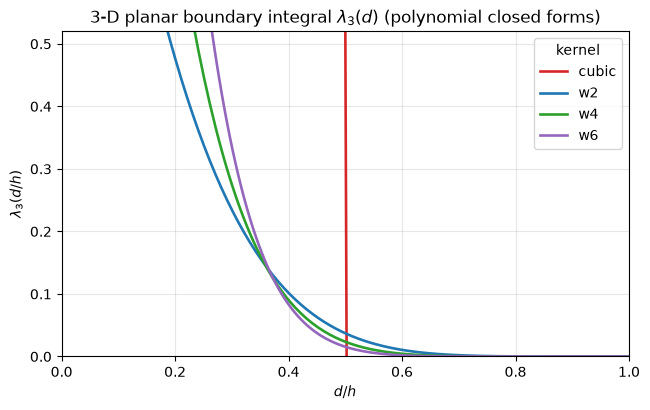

In [6]:

# exact boundary values straight from the exported polynomials
rows = ["| kernel | lambda_3(0) | lambda_3(1) | deg |", "|---|---|---|---|"]
for k in K:
    c = data["3d"][("cubic", "b1")] if k == "cubic" else data["3d"][(k, "all")]
    deg = len(c) - 1 if k != "cubic" else 6
    rows.append(f"| {k} | {planar3d(k, 0)} | {planar3d(k, 1)} | {deg} |")
print("\n".join(rows))

fig, ax = plt.subplots(figsize=(6.6, 4.2))
for k in K:
    ax.plot(dgrid, lam3_np(k, dgrid), color=COLORS[k], lw=1.9, label=k)
ax.set_xlabel(r"$d/h$"); ax.set_ylabel(r"$\lambda_3(d/h)$")
ax.set_title(r"3-D planar boundary integral $\lambda_3(d)$ (polynomial closed forms)")
ax.legend(title="kernel"); ax.set_xlim(0, 1); ax.set_ylim(0, 0.52)
fig.tight_layout(); fig.savefig(FIG / "fig5_lambda_3d.png", bbox_inches="tight")
plt.show()


## 4. Curvature: the solid sphere

Now the boundary is a solid ball of radius `R`; the particle sits at
$D = R + d$ from the center.  The radius-`q` shell intersects the ball in a
spherical cap,

$$A(q) = \frac{\pi q}{D}\Big(R^2 - D^2 + 2Dq - q^2\Big),
\qquad q \in [d,\ \min(1, 2R+d)]$$

which gives **two branches** (the shell either dies at the support edge or
engulfs the whole obstacle):

* **branch 1**, $2R + d \ge 1$:  $q_{max} = 1$ (the usual $R \gg h$ regime)
* **branch 2**, $2R + d < 1$:   $q_{max} = 2R + d$

Both close to the **rational** form $\lambda_{sph}(R,d) = N(R,d)/(R+d)$ with
$N$ a polynomial in $R, d$ (branch 1 is linear in R — the cap area is).
The planar limit $R \to \infty$ reproduces §3 exactly, and the branches join
exactly on $2R + d = 1$ (verified symbolically).

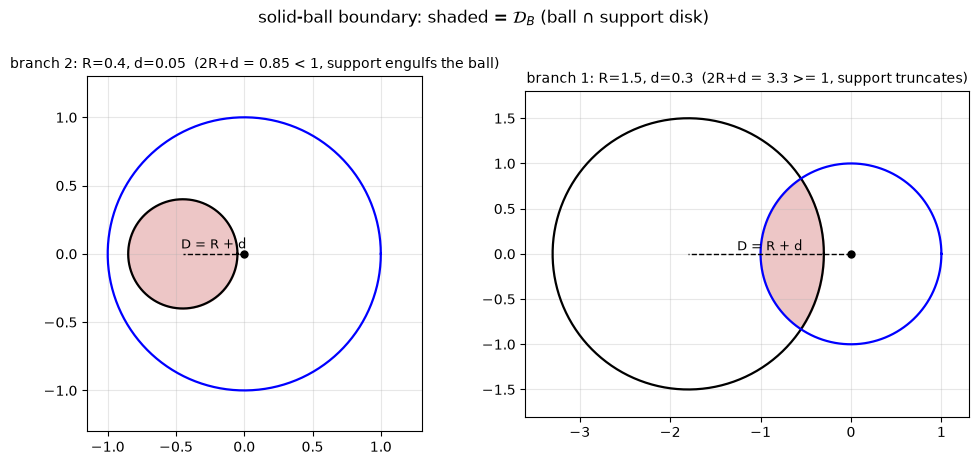

In [7]:

import matplotlib.pyplot as plt

def sphere_panel(ax, R, d, title):
    D = R + d
    t = np.linspace(0, 2*np.pi, 400)
    # overlap region in particle-centered coords (ball center at (-D, 0))
    umin = max(-1.0, -D - R); umax = min(1.0, -D + R)
    uu = np.linspace(umin, umax, 400)
    vmax = np.minimum(np.sqrt(np.clip(1 - uu**2, 0, None)),
                      np.sqrt(np.clip(R**2 - (uu + D)**2, 0, None)))
    ax.fill_between(uu, -vmax, vmax, color="indianred", alpha=0.35)
    ax.plot(-D + R*np.cos(t), R*np.sin(t), "k-", lw=1.6)     # ball
    ax.plot(np.cos(t), np.sin(t), "b-", lw=1.6)              # support
    ax.plot([0, -D], [0, 0], "k--", lw=1)
    ax.text(-D/2, 0.04, " D = R + d ", fontsize=9, ha="center")
    ax.plot(0, 0, "ko", ms=5)
    ax.set_aspect("equal"); ax.set_title(title, fontsize=10)
    ax.set_xlim(-D - R - 0.3, 1.3); ax.set_ylim(-max(R, 1) - 0.3, max(R, 1) + 0.3)

fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.6))
R, d = 0.4, 0.05
sphere_panel(axes[0], R, d,
             f"branch 2: R={R}, d={d}  (2R+d = {2*R+d:.2f} < 1, support engulfs the ball)")
R, d = 1.5, 0.3
sphere_panel(axes[1], R, d,
             f"branch 1: R={R}, d={d}  (2R+d = {2*R+d:.1f} >= 1, support truncates)")
fig.suptitle("solid-ball boundary: shaded = $\\mathcal{D}_B$ (ball $\\cap$ support disk)", y=1.0)
fig.tight_layout(); fig.savefig(FIG / "fig6_sphere_geometry.png", bbox_inches="tight")
plt.show()


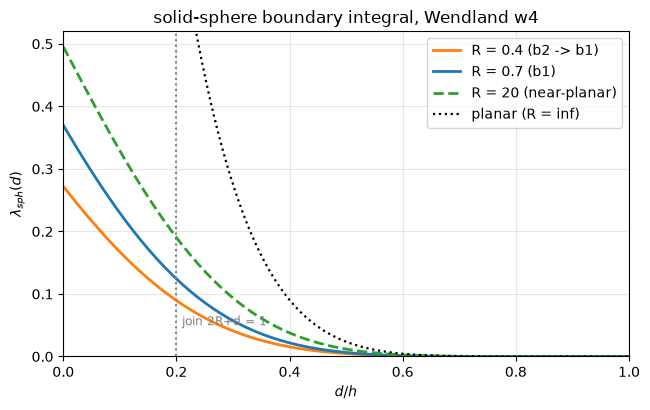

In [8]:

# lambda_sphere(d) for w4: branch 2 (R=0.4, joins at d=0.2), branch 1 (R=0.7),
# and the planar-limit curve (R=20)
dgrid = np.linspace(1e-4, 1.0, 140)
def lamS(Rstr, dg):
    R = Fraction(Rstr)
    return [float(sphere("w4", R, Fraction(str(round(x, 12))))) for x in dg]

fig, ax = plt.subplots(figsize=(6.6, 4.2))
ax.plot(dgrid, lamS("0.4", dgrid), "tab:orange", lw=2.0, label="R = 0.4 (b2 -> b1)")
ax.plot(dgrid, lamS("0.7", dgrid), "tab:blue", lw=2.0, label="R = 0.7 (b1)")
ax.plot(dgrid, lamS("20", dgrid), "tab:green", lw=2.0, ls="--", label="R = 20 (near-planar)")
ax.plot(dgrid, lam3_np("w4", dgrid), "k:", lw=1.6, label="planar (R = inf)")
ax.axvline(0.2, ls=":", c="grey")
ax.text(0.21, 0.05, "join 2R+d = 1", fontsize=8.5, color="grey")
ax.set_xlabel(r"$d/h$"); ax.set_ylabel(r"$\lambda_{sph}(d)$")
ax.set_title(r"solid-sphere boundary integral, Wendland w4")
ax.legend(title=""); ax.set_xlim(0, 1); ax.set_ylim(0, 0.52)
fig.tight_layout(); fig.savefig(FIG / "fig7_sphere_lambda.png", bbox_inches="tight")
plt.show()


In [9]:

# planar-limit quality: exact closed-form difference (R = 20)
rows = ["| kernel (Wendland) | d | \u03bbsph(R=20, d) \u2212 \u03bb\u2083(d) |", "|---|---|---|"]
for k in ["w2", "w4", "w6"]:
    for dn in [1, 3, 5]:
        d = Fraction(dn, 10)
        diff = sphere(k, 20, d) - planar3d(k, d)
        rows.append(f"| {k} | {float(d):.1f} | {float(diff):.3e} |")
print("\n".join(rows))


| kernel (Wendland) | d | λsph(R=20, d) − λ₃(d) |
|---|---|---|
| w2 | 0.1 | -4.822e-03 |
| w2 | 0.3 | -2.649e-03 |
| w2 | 0.5 | -7.185e-04 |
| w4 | 0.1 | -4.126e-03 |
| w4 | 0.3 | -1.880e-03 |
| w4 | 0.5 | -3.348e-04 |
| w6 | 0.1 | -3.631e-03 |
| w6 | 0.3 | -1.372e-03 |
| w6 | 0.5 | -1.605e-04 |


## 5. Validation

Three independent layers, none of which shares code with the closed forms'
origin:

1. **Maple, exact arithmetic** — every identity in `maple/01_planar.mpl` and
   `maple/03_sphere.mpl` is checked *symbolically* (branch joins, planar
   limit, monomial-basis derivative identities), plus 50-digit quadrature.
2. **Python, 40-digit mpmath oracles** — `curvbound.oracle` re-integrates the
   defining integrals from scratch (no shared code with `curvbound.symbolic`).
3. **Exact rational checks** — boundary values and branch joins as
   `fractions.Fraction` arithmetic, and a *true 2-D Cartesian* quadrature
   (no 1-D shell reduction) in `tests/test_planar.py`.

In [10]:

mp.mp.dps = 40
d2 = [mp.mpf(n)/100 for n in (1, 10, 25, 49, 51, 60, 75, 90)]
d3 = [Fraction(n, 100) for n in (1, 3, 4, 5, 7, 9, 99)]

def worst(fn, ks, ds):
    w = mp.mpf(0)
    for k in ks:
        for x in ds:
            w = max(w, abs(fn(k, x)))
    return w

rows = ["| check | points | worst error (closed form \u2212 oracle) |", "|---|---|---|"]
w = worst(lambda k, x: planar2d(k, x) - quad_planar2d(k, x), K, d2)
rows.append(f"| 2-D planar | 4 \u00d7 8 | {mp.nstr(w, 4)} |")
w = worst(lambda k, x: mp.mpf(str(planar3d(k, x))) - quad_planar3d(k, x), K, d3)
rows.append(f"| 3-D planar | 4 \u00d7 7 | {mp.nstr(w, 4)} |")
w = mp.mpf(0)
for k in ["w2", "w4", "w6"]:
    for R in ("1/2", "1", "2"):
        for x in d3:
            w = max(w, abs(mp.mpf(str(sphere(k, Fraction(R), x))) - quad_sphere(k, R, x)))
rows.append(f"| sphere (w2/w4/w6 \u00d7 R \u00d7 d) | 3 \u00d7 3 \u00d7 7 | {mp.nstr(w, 4)} |")
print("\n".join(rows))


| check | points | worst error (closed form − oracle) |
|---|---|---|
| 2-D planar | 4 × 8 | 1.516e-39 |
| 3-D planar | 4 × 7 | 5.74e-42 |
| sphere (w2/w4/w6 × R × d) | 3 × 3 × 7 | 4.018e-41 |


## 6. h-scaling: one formula for every resolution

Because the closed forms are functions of $d/h$ only, the physical integral
with explicit support radius $h$,

$$\int_{r=d}^{h} \frac{C_3}{h^3}\hat W\!\left(\frac{r}{h}\right) 2\pi r (r-d)\,dr
\;=\; \lambda_3(d/h),$$

reuses the same curve at every particle resolution (verified numerically in
`tests/test_planar.py::test_h_scaling_3d`).

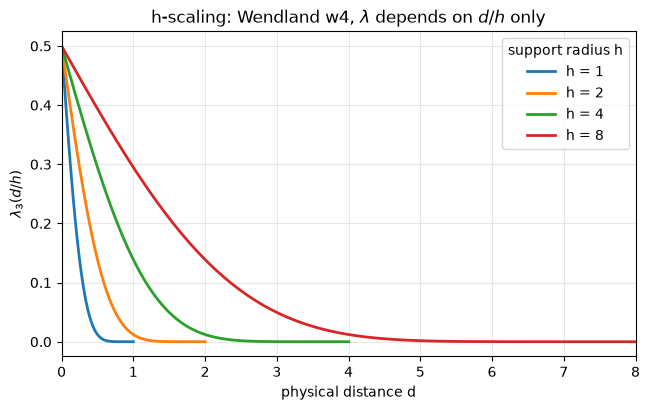

In [11]:

fig, ax = plt.subplots(figsize=(6.6, 4.2))
for h in [1, 2, 4, 8]:
    dphys = np.linspace(1e-3, h, 140)
    xi = dphys / h
    ys = [float(planar3d("w4", Fraction(str(round(x, 12))))) for x in xi]
    ax.plot(dphys, ys, lw=2.0, label=f"h = {h}")
ax.set_xlabel("physical distance d"); ax.set_ylabel(r"$\lambda_3(d/h)$")
ax.set_title(r"h-scaling: Wendland w4, $\lambda$ depends on $d/h$ only")
ax.legend(title="support radius h"); ax.set_xlim(0, 8)
fig.tight_layout(); fig.savefig(FIG / "fig8_h_scaling.png", bbox_inches="tight")
plt.show()


## 7. Next steps & references

**Next on the roadmap** (see `PLAN.md`):
* cylinder boundary (the 3-D curved case after the sphere),
* 2-D circle boundary (chord of a disk — same by-parts pattern as §2),
* particles *inside* the solid ($d < 0$: $\lambda(d) = 1 - \lambda(-d)$ for
  planar by symmetry), gradient terms (paper §5.4).

**References**
* Winchenbach, Akhunov, Kolb, *Semi-Analytic Boundary Handling Below Particle
  Resolution for SPH*, ACM TOG 2020 — eqs. (3)–(4), (11)–(18), (56)–(64).
* warpSPHCore: `src/warpSPHCore/kernels/` (kernel conventions),
  `scripts/kernels/kernel_specs.yaml` (C constants).
* Full derivation write-up: `docs/derivation.md`.  Status & roadmap:
  `PLAN.md`.

**File map**
```
maple/00_setup.mpl          kernel table, normalization, F(n,p,x) basis
maple/01_planar.mpl         2-D + 3-D planar, all kernels  -> src/warpSPHBoundaries/data/symbolic/planar_export.txt
maple/03_sphere.mpl         solid sphere (Wendland)        -> src/warpSPHBoundaries/data/symbolic/sphere_export.txt
src/warpSPHBoundaries/curvbound/           kernel table, closed-form evaluators, mpmath oracles
tests/                      pytest suite (49 tests, all oracles independent)
notebooks/demo.ipynb        this notebook
```